<a href="https://colab.research.google.com/github/sherjahong1r/Machine-Learning-Lessons/blob/main/01_working_with_audio_using_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
import librosa
import librosa.display

# IPython.display as ipd: Bu modul IPython muhitida, masalan, Jupyter Notebook yoki Google Colab'da turli xil boy kontentlarni,
#  masalan, audio pleerlarni, rasmlarni yoki videolarni to'g'ridan-to'g'ri ko'rsatish uchun ishlatiladi.
# librosa: Bu audio va musiqa tahlili uchun Python kutubxonasi. U audio fayllarni yuklash, xususiyatlarni ajratib olish
#  (masalan, ohang, tempo va ritm) va boshqa turli xil audio ishlov berish vazifalarini bajarish uchun funksiyalarni ta'minlaydi.
# librosa.display: librosa'ning ushbu kichik moduli audio signallari va ularning ajratib olingan xususiyatlarini
#  vizualizatsiya qilish uchun maxsus mo'ljallangan. U matplotlib bilan yaxshi ishlaydi va to'lqin shakllari,
#  spektrogrammalar va boshqa vizualizatsiyalarni yaratib, audio ma'lumotlarni vizual tushunishni osonlashtiradi

In [ ]:
ipd.Audio("/content/audio.mp3")
# yuqorida import qilgan ipd bilan o'qib olyabmiz

In [ ]:
# # list of all audio files
# import os
# audio_files = os.listdir("audio")
# audio_files

# Shu folder ostidagi barcha audiolar ro'yxatini ko'rish mumkin ammo bizda bizda bunday audiodan tashkil topgan
# audio folder yo'q

In [ ]:
data, sr = librosa.load("/content/audio.mp3")

In [ ]:
data

# data: Bu o'zgaruvchi audio fayldan yuklab olingan ovoz to'lqinining vaqt seriyasini (audio signalni)
# o'z ichiga oladi. Ya'ni, bu fayldagi har bir vaqt nuqtasidagi ovoz balandligi (amplituda) qiymatlari majmuasidir.

array([ 6.8514370e-12,  8.3128670e-13,  5.4599368e-12, ...,
        1.3780183e-05,  7.4437894e-06, -4.4509861e-06], dtype=float32)

In [ ]:
sr

# sr: Bu o'zgaruvchi audio faylning namunalash chastotasini (sampling rate) o'z ichiga oladi. U bir sekundda nechta namuna
# (nuqta) olinganini bildiradi. librosa sukut bo'yicha ko'pincha 22050 Hz namunalash chastotasidan foydalanadi.

22050

In [ ]:
print(f'y: {data[:10]}')
print(f'shape y: {data.shape}')
print(f'sr: {sr}')

# print(f'y: {data[:10]}'): data massivining (audio signalining) dastlabki 10 ta elementini ko'rsatadi.
# print(f'shape y: {data.shape}'): data massivining shaklini, ya'ni uning o'lchamlarini ko'rsatadi. Bu signalda qancha namuna borligini bildiradi.
# print(f'sr: {sr}'): sr o'zgaruvchisining qiymatini ko'rsatadi, bu audio faylning namunalash chastotasi (sampling rate) hisoblanadi.


y: [ 6.8514370e-12  8.3128670e-13  5.4599368e-12 -2.5242083e-12
  6.0994204e-12 -8.3699974e-12  7.9670289e-12  2.0467421e-11
  1.5930894e-11  3.3648098e-11]
shape y: (166698,)
sr: 22050


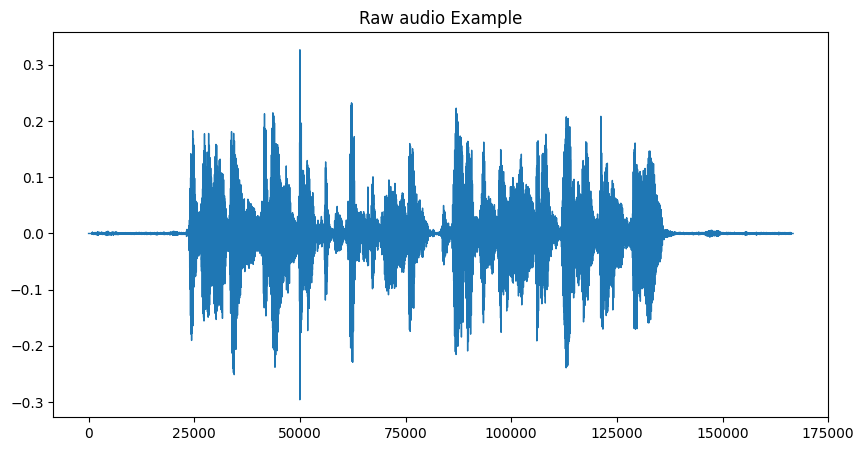

In [ ]:
pd.Series(data).plot(figsize=(10, 5),
                  lw=1,
                  title='Raw audio Example',
               )
plt.show()

# Bu kod data o'zgaruvchisidagi audio signalini grafik shaklda ko'rsatish uchun ishlatiladi:
# pd.Series(data): data (audio ma'lumotlari) o'zgaruvchisini pandas Series ob'ektiga aylantiradi.
#  Bu unga .plot() kabi vizualizatsiya usullaridan foydalanish imkonini beradi.
# .plot(figsize=(10, 5), lw=1, title='Raw audio Example'): Series ob'ektini grafik shaklda chizadi.
#  Bunda figsize grafikaning o'lchamini, lw chiziq qalinligini belgilaydi va title grafikaga sarlavha beradi.
# plt.show(): Chizilgan grafikani ekranda ko'rsatadi.

<Figure size 1200x300 with 0 Axes>

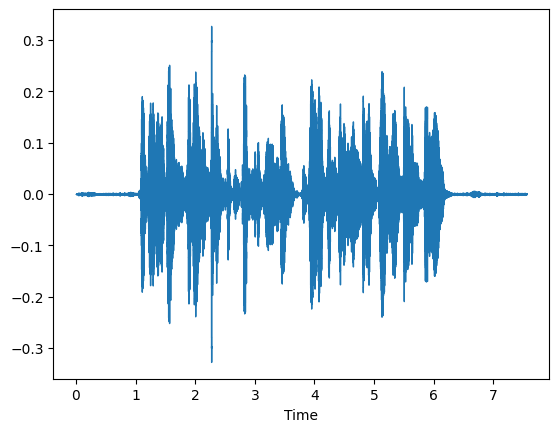

In [ ]:
plt.figure(figsize=(12, 3))
plt.figure()
librosa.display.waveshow(data, sr=sr)

# librosa.display.waveshow(data, sr=sr): Bu librosa kutubxonasining maxsus funksiyasi bo'lib, audio signalining to'lqin shaklini
# (waveform) chizadi. U data (audio ma'lumotlari) va sr (namunalash chastotasi) parametrlari yordamida audio to'lqinni vizualizatsiya qiladi.
# Oldingi koddan farqi:
# Ikkala kod ham audio to'lqinini ko'rsatadi, ammo farq ularning maqsadida va ixtisosligida:
# pd.Series(data).plot(): Bu Pandas kutubxonasining umumiy chizish funksiyasi. U data ni oddiy raqamlar seriyasi deb
# biladi va uni vaqtga bog'liq grafik sifatida chizadi. Bu asosan, har qanday raqamli qatorni ko'rsatish uchun ishlatiladi.
# librosa.display.waveshow(data, sr=sr): Bu Librosa kutubxonasining audio tahlili uchun maxsus mo'ljallangan funksiyasi.
#  U audio to'lqinining xususiyatlarini (masalan, namunalash chastotasini) hisobga oladi va odatda audio vizualizatsiyasi
#   uchun optimallashtirilgan, masalan, y o'qida ovoz amplitudasini va x o'qida vaqtni ko'rsatishda aniqroq bo'ladi.
#    U audio ma'lumotlarni tushunadigan va ularni tegishli tarzda ko'rsatadigan aqlliroq funksiyadir.



In [ ]:
melspec = librosa.feature.melspectrogram(y=data, sr=sr)

# Bu qator librosa kutubxonasining melspectrogram funksiyasidan foydalanib, audio signalidan ( data ) Mel spektrogrammasini
# hisoblaydi. sr (namunalash chastotasi) ham beriladi. Mel spektrogrammasi ovozni chastota va vaqt bo'yicha vizual tasvirlashning
# bir usuli bo'lib, inson qulog'i tovushni qanday qabul qilishiga o'xshash tarzda chastotalarni miqyoslashtiradi.
# Bu ko'pincha audio tahlilida, masalan, musiqa janrini aniqlash yoki nutqni tanib olishda ishlatiladi.

In [ ]:
melspec

array([[4.3456087e-08, 1.1151541e-05, 5.1427782e-05, ..., 4.0834566e-05,
        4.8038160e-05, 7.4051200e-06],
       [3.1232343e-08, 2.5336823e-05, 5.7900565e-05, ..., 2.8029070e-04,
        1.5814045e-04, 4.2186584e-05],
       [1.2341967e-07, 7.6995748e-05, 4.4277770e-04, ..., 1.8762166e-03,
        2.1913212e-03, 3.4941704e-04],
       ...,
       [6.3884706e-09, 1.2566819e-06, 5.9796730e-06, ..., 4.6069204e-06,
        4.4296044e-06, 8.7597738e-07],
       [5.0132574e-09, 7.4576684e-07, 3.2982309e-06, ..., 2.6937341e-06,
        3.3084204e-06, 9.1464705e-07],
       [6.0801181e-10, 5.5708508e-08, 2.2026884e-07, ..., 1.3677193e-07,
        1.8720715e-07, 7.0561192e-08]], dtype=float32)

In [ ]:
log_s = librosa.amplitude_to_db(melspec)
# Bu qator librosa kutubxonasining amplitude_to_db funksiyasidan foydalanib, avval hisoblangan melspec
#  (Mel spektrogrammasi) qiymatlarini desibellarga (dB) o'zgartiradi. Bu operatsiya tovushni tahlil qilishda juda
#  muhim, chunki inson qulog'i tovush balandligini logarifmik shkalada qabul qiladi. Desibellarga o'tkazish orqali
#  tovushning dinamik diapazoni (eng past va eng baland ovoz o'rtasidagi farq) yaxshiroq ifodalanadi va
#  vizualizatsiya hamda keyingi tahlillar uchun qulayroq bo'ladi.



In [ ]:
log_s

array([[-34.009247, -34.009247, -34.009247, ..., -34.009247, -34.009247,
        -34.009247],
       [-34.009247, -34.009247, -34.009247, ..., -34.009247, -34.009247,
        -34.009247],
       [-34.009247, -34.009247, -34.009247, ..., -34.009247, -34.009247,
        -34.009247],
       ...,
       [-34.009247, -34.009247, -34.009247, ..., -34.009247, -34.009247,
        -34.009247],
       [-34.009247, -34.009247, -34.009247, ..., -34.009247, -34.009247,
        -34.009247],
       [-34.009247, -34.009247, -34.009247, ..., -34.009247, -34.009247,
        -34.009247]], dtype=float32)

Text(0.5, 1.0, 'Mel power spectogram')

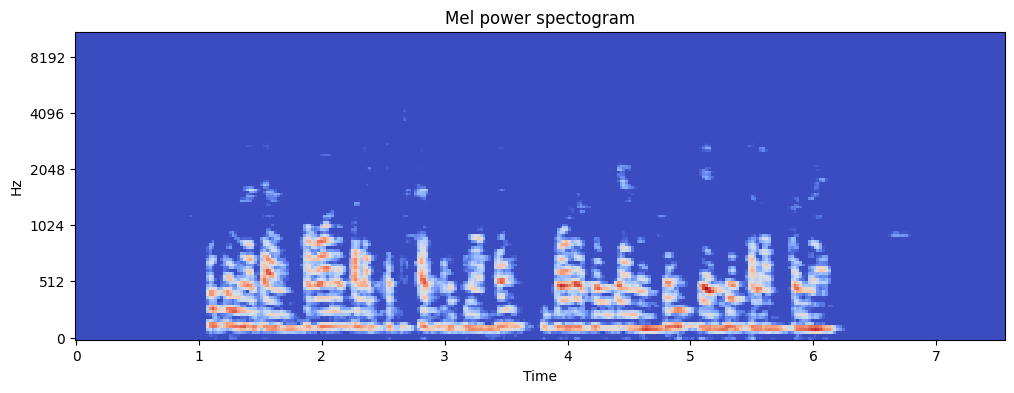

In [ ]:
plt.figure(figsize=(12, 4))
librosa.display.specshow(log_s, x_axis='time', y_axis='mel')
# Bu librosa kutubxonasining funksiyasi bo'lib, Mel spektrogrammasini vizualizatsiya qilish uchun ishlatiladi.
# log_s desibellarga o'tkazilgan spektrogramma ma'lumotlarini bildiradi. x_axis='time' gorizontal o'qni vaqt
# sifatida, y_axis='mel' vertikal o'qni Mel shkalasidagi chastota sifatida belgilaydi
plt.title('Mel power spectogram')

## Bajarilgan ishlar:

## Audio fayl yuklandi va tinglandi.

## Uning ma'lumotlari tahlil qilindi (signal, namunalash chastotasi).

## Audio to'lqin shakli va Mel spektrogrammasi vizualizatsiya qilindi.